# Customer Segmentation Analysis using RFM (Recency, Frequency, Monetary)

This project focuses on performing Customer Segmentation using RFM (Recency, Frequency, Monetary) analysis based on transactional data from an online retail store in UK. The goal of this analysis is to better understand customer purchasing behavior and identify different customer groups based on their value and engagement level. By leveraging historical transaction data, I aim to segment customers into meaningful categories such as high-value customers, loyal customers, potential customers, and at-risk customers.

### Customer segmentation

The customer segmentation is an effective method that enables us to get better know our clients and to better respond to their various needs. One of the most widely used techniques is RFM analysis, which allows us to create personalized special offers to improve sales and decrease customer retention.

RFM stands for Recency, Frequency, Monetary Value and it is the technique of customer segmentation based on their transaction history. The RFM analysis is based on three criteria, which measure different customer characteristics:

Recency: Time since the last purchase/order of the client;

Frequency: Total number of purchases of a customer made in a given time period;

Monetary Value: Total money the customer spent in a given period of time.

Customer segmentation can be performed using the classic RFM method, assigning them ratings from 1 to 4. Four is the best / highest value and one is the lowest / worst value. The final RFM score is calculated by combining the individual score numbers into one column to create RFM value classes for our customers.

Through this project, I will:
- Clean and preprocess raw transactional data
- Build RFM metrics for each customer
- Segment customers based on their value and behavior
- Provide actionable business insights to support marketing and retention strategies

In [71]:
%pip install pandas
%pip install altair
%pip install seaborn
%pip install matplotlib
%pip install scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# dont show warnings
import warnings
warnings.filterwarnings('ignore')

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip in

# Part1: Data Understanding 
The dataset used in this project contains real-world retail transaction records, including invoice details, product information, quantities, unit prices, and customer ID. 
The online retail data consists of 1067371 observations(rows) and 8 variables(columns), including: 'Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID' and 'Country'.

In [2]:
df = pd.read_csv('online_retail.csv')

pd.set_option('display.max_columns', None)  
pd.set_option('display.max_rows', None)      
pd.set_option('display.width', 1000)         
pd.set_option('display.colheader_justify', 'center')    


print("Data Set:")
df.head()

Data Set:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.shape

(1067371, 8)

In [67]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [69]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [70]:
df.dtypes

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

In [71]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country'], dtype='object')

# Part2: Data Cleaning
Before start data analysis, it is crucial to clean the data set. 

First, I checked if there are any missing values, and found out that a significant portion of Customer ID is missing, which are essential for customer-level analysis. Therefore, these records are removed to ensure accurate RFM segmentation. Also I dropped rows with missing description. 

Then, I focused on the 'Quantity' column. Since negative represents returns or cancellations, I excluded those and only left actual purchases for further analysis. I did the same thing on 'Price' to get positive values only. 

I also noticed that the the data type for 'InvoiceDate' is 'object', which is not suitable for making time-based analysis. In addition, Customer ID should be a categorical variable instead of a numerical. 

I created a new variable 'Revenue' representing the multiplication of 'Quantity' and 'Price', which provides a whole picture of the money spent. 

Finally, I checked if there are any duplicates and removed them. 

In [72]:
#check missing values in the dataset
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [4]:
#handle missing values in the 'Description' column
df = df.dropna(subset=['Description'])

In [5]:
#handle missing values in the 'Customer ID' column
df=df.dropna(subset=['Customer ID'])

In [6]:
#check if this is handled properly
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [7]:
#filter 'Quantity' column for positive value only
df = df[df['Quantity'] > 0]

In [8]:
#filter for negative prices
df=df[df['Price']>0]

In [9]:
#convert data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(str)

In [10]:
#create TotalPrice column
df['Revenue'] = df['Quantity'] * df['Price']

In [11]:
#check and remove duplicates
df.duplicated().sum()
df = df.drop_duplicates()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  object        
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  object        
 7   Country      779425 non-null  object        
 8   Revenue      779425 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 59.5+ MB


# Part3: Exploratory Data Analysis  

I first investigate the monthly sales trend across three years and the result indicates that there are some minor fluctuations between months in each year. Notice that there are two peaks in the plot, one happened in 2010-11 and the other once occurred in 2011-11, both were in November. Overall, from the plot, I could tell that there exits a seasonal trend: sales are usually higher at the end of the year, probably due to the arrival of Christmas Holiday. 

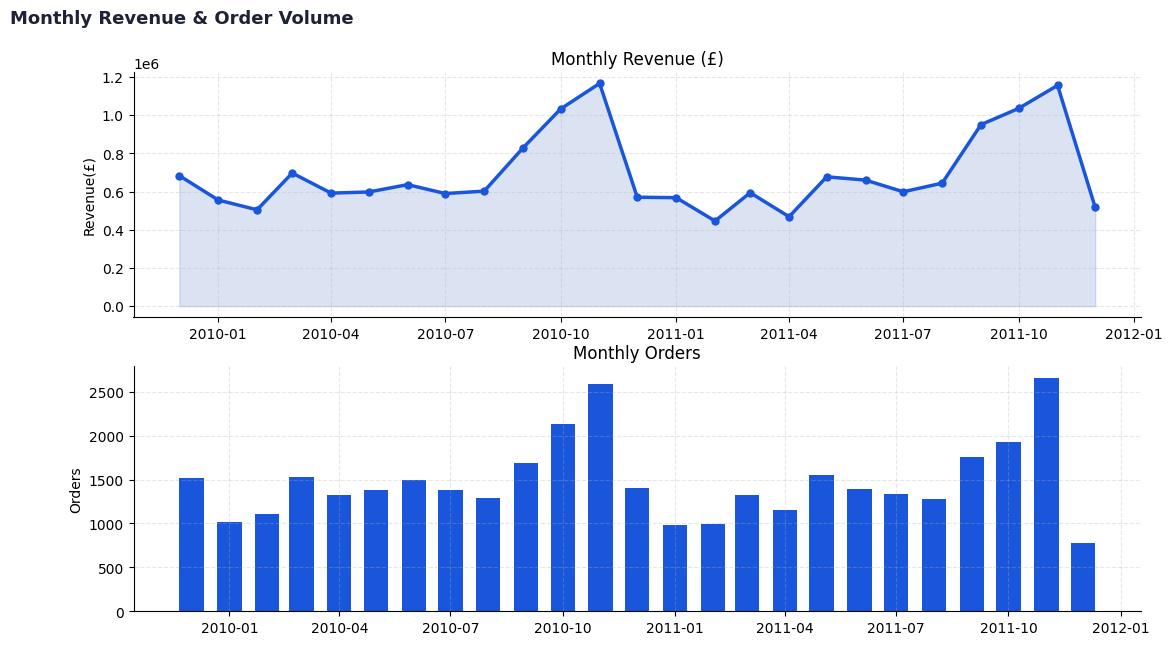

In [13]:
df["YearMonth"]   = df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

def plot_style(ax, title="", xlabel="", ylabel=""):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    ax.grid(True, linestyle="--", alpha=0.3)

monthly = (df.groupby("YearMonth").agg(Revenue=("Revenue","sum"), Orders=("Invoice","nunique")).reset_index())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7))
fig.text(0.03, 0.97, "Monthly Revenue & Order Volume", color="#1E2235",fontsize=13, fontweight="bold", va="top")

ax1.fill_between(monthly["YearMonth"], monthly["Revenue"],color="#1044b5", alpha=0.15)

ax1.plot(monthly["YearMonth"], monthly["Revenue"],color="#1a56db", lw=2.5, marker="o", ms=5)
plot_style(ax1, "Monthly Revenue (£)", ylabel="Revenue(£)")

ax2.bar(monthly["YearMonth"], monthly["Orders"],color="#1a56db", width=20, linewidth=0.4)
plot_style(ax2, "Monthly Orders", ylabel="Orders")

Then, I plotted over the monthly AOV trends. According to the plot below, we could see that the AOV shows a "sawtooth" pattern with frequent peaks and sharp drops, suggesting that purchasing behavior varies greatly by month. Because this data shows sharp spikes specifically in January 2010, January 2011, and December 2011, it suggests a seasonal promotion may even further booster our sales. 

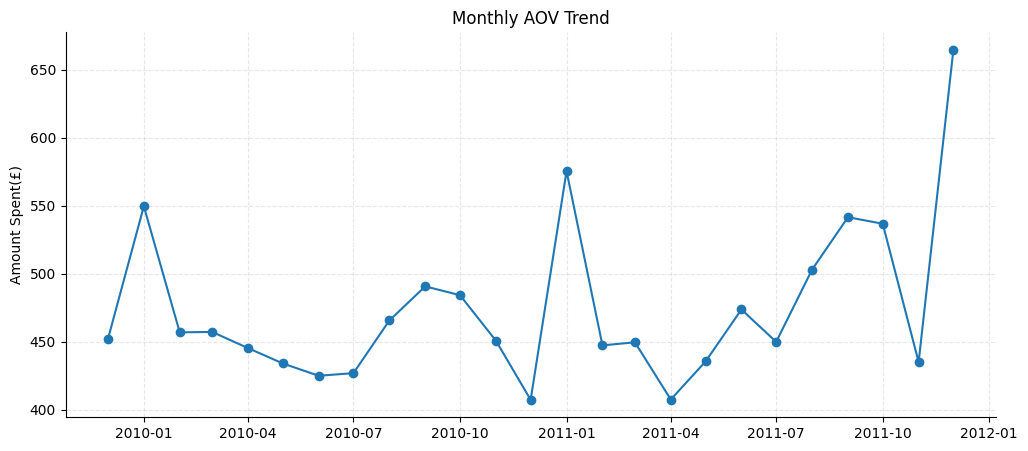

In [14]:
order_invoice = df.groupby(["YearMonth", "Invoice"])["Revenue"].sum().reset_index()

monthly_aov = order_invoice.groupby("YearMonth")["Revenue"].mean().reset_index()
monthly_aov.columns = ["YearMonth", "AOV"]

plt.figure(figsize=(12,5))
plt.plot(monthly_aov["YearMonth"], monthly_aov["AOV"], marker="o")

plot_style(plt.gca(), "Monthly AOV Trend", ylabel="Amount Spent(£)")

plt.show()

Finally, I investigate the top 10 popular products ranking by quantity sold. This can reveal customer preferences. 

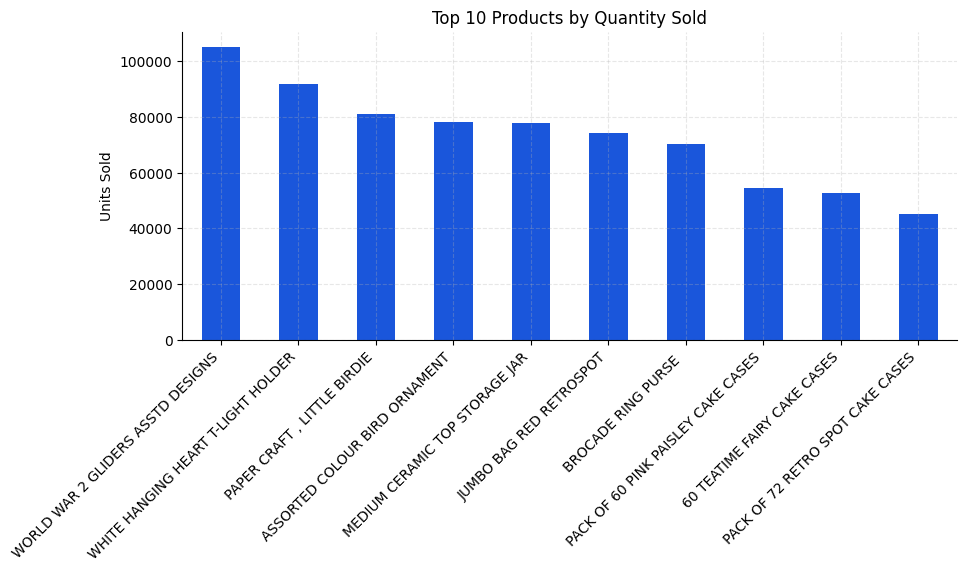

In [34]:
top_products= (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,4))
top_products.plot(kind="bar", color="#1a56db")

plot_style(plt.gca(), "Top 10 Products by Quantity Sold", ylabel="Units Sold")

plt.xticks(rotation=45, ha="right")
plt.show()

# Part4: RFM Analysis

RFM (Recency, Frequency, Monetary) analysis is a behavior-based approach that groups customers into segments. It groups the customers on the basis of their previous purchase transactions. How recently, how often, and how much did a customer buy. For example, there is a segment of customer who is the big spender but what if they purchased only once? Do they often purchase our product? How can we better serve our big spender? Also, It helps managers to carry out effective promotions for personalized service.

- Recency (R): Who have purchased recently? (least recency)
- Frequency (F): Who has purchased frequently? (high frequency)
- Monetary Value(M): Who have high purchase amount? (high monetary value)

In [15]:
#the latest transaction date

max_trans_date = max(df['InvoiceDate']).date()
max_trans_date

datetime.date(2011, 12, 9)

In [23]:
# Creating a RFM table that will contain all the values for recency , frequency and Monetary data. 

comparison_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm_table = df.groupby(['Customer ID']).agg({'InvoiceDate': lambda date : (comparison_date - date.max()).days,
                                                            "Invoice": "nunique", 
                                                            'Revenue' : lambda r : sum(r)})

In [24]:
#rename columns of the rfm_table
rfm_table.columns = ["Recency", "Frequency", "Monetary"]
rfm_table.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [26]:
# Dividing the recency, frequency and monetary into 4 quartiles (min, 25%, 50%, 75% and max).

rfm_table['r_quartile'] = pd.qcut(rfm_table['Recency'].rank(method="first"), 4, ['4','3','2','1'])
rfm_table['f_quartile'] = pd.qcut(rfm_table['Frequency'].rank(method="first"), 4, ['1','2','3','4'])
rfm_table['m_quartile'] = pd.qcut(rfm_table['Monetary'].rank(method="first"), 4, ['1','2','3','4'])

In [28]:
rfm_table.head(10)

,Recency,Frequency,Monetary,r_quartile,f_quartile,m_quartile
Customer ID,,,,,,
12346.0,326,12,77556.46,2,4,4
12347.0,2,8,4921.53,4,4,4
12348.0,75,5,2019.40,3,3,3
12349.0,19,4,4428.69,4,3,4
12350.0,310,1,334.40,2,1,1
12351.0,375,1,300.93,2,1,1
12352.0,36,10,2849.84,3,4,4
12353.0,204,2,406.76,2,2,2
12354.0,232,1,1079.40,2,1,3


In [ ]:
#create RFM segments
#The importance order is: Recency > Frequency > Monetary
def segment(row):
    if row["r_quartile"] >= "4" and row["f_quartile"] >= "4":
        return "Champions"
    elif row["r_quartile"] >= "3" and row["m_quartile"] >= "3":
        return "Loyal Customers"
    elif row["r_quartile"] <= "2":
        return "At Risk"
    else:
        return "Others"

rfm_table["Segment"] = rfm_table.apply(segment, axis=1)

In [ ]:
#dropped my previous attempt
rfm_table.drop(columns=["customer_title"], inplace=True)

In [45]:
rfm_table.head(10)

,Recency,Frequency,Monetary,r_quartile,f_quartile,m_quartile,rfm_score,Segment
Customer ID,,,,,,,,
12346.0,326,12,77556.46,2,4,4,244,At Risk
12347.0,2,8,4921.53,4,4,4,444,Champions
12348.0,75,5,2019.40,3,3,3,333,Loyal Customers
12349.0,19,4,4428.69,4,3,4,434,Loyal Customers
12350.0,310,1,334.40,2,1,1,211,At Risk
12351.0,375,1,300.93,2,1,1,211,At Risk
12352.0,36,10,2849.84,3,4,4,344,Loyal Customers
12353.0,204,2,406.76,2,2,2,222,At Risk
12354.0,232,1,1079.40,2,1,3,213,At Risk


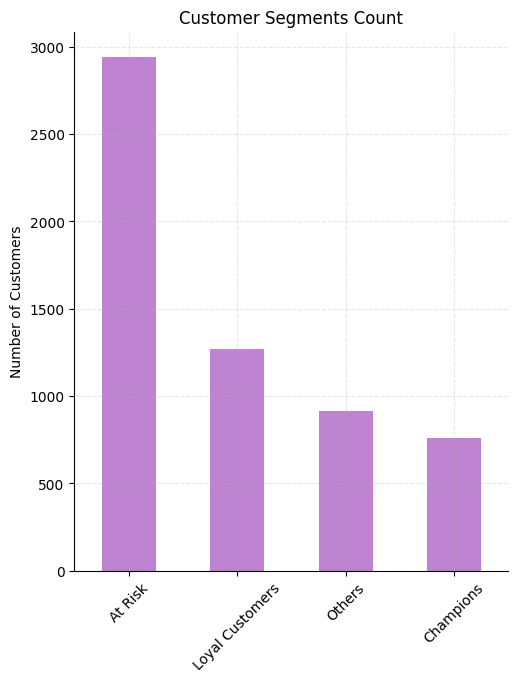

In [68]:
#customer segment distribution
segment_counts = rfm_table["Segment"].value_counts()

plt.figure(figsize=(5.6,7))
segment_counts.plot(kind="bar", color="#BE84D2")

plot_style(plt.gca(), "Customer Segments Count", ylabel="Number of Customers")
plt.xticks(rotation=45)
plt.show()

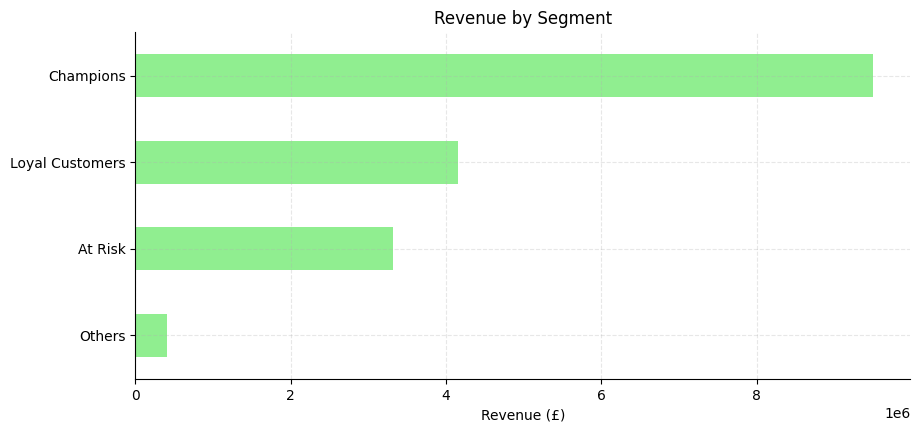

In [ ]:
#plot to see which segment spend the most
segment_revenue = rfm_table.groupby("Segment")["Monetary"].sum().sort_values()

plt.figure(figsize=(10,4.5))
segment_revenue.plot(kind="barh", color="lightgreen")

plot_style(plt.gca(), "Revenue by Segment", xlabel="Revenue (£)")
plt.show()

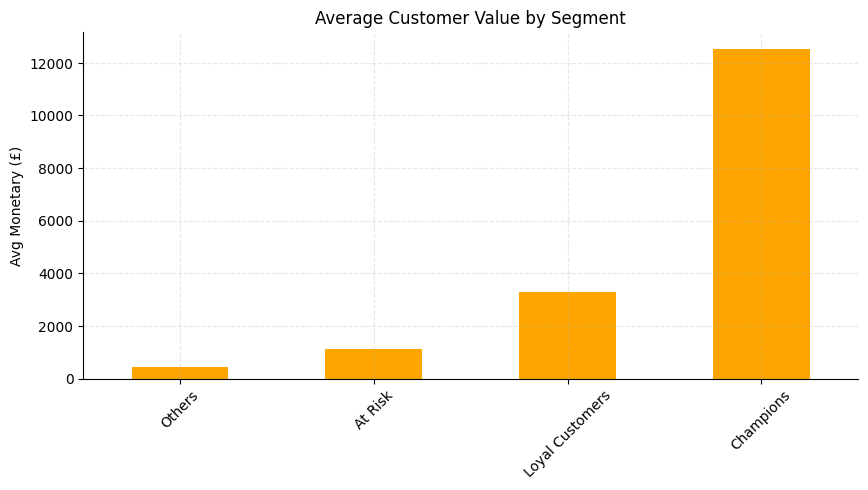

In [ ]:
#average purchase monetary value by segment
segment_avg = rfm_table.groupby("Segment")["Monetary"].mean().sort_values()

plt.figure(figsize=(10,4.5))
segment_avg.plot(kind="bar", color="orange")

plot_style(plt.gca(), "Average Customer Value by Segment", ylabel="Avg Monetary (£)")
plt.xticks(rotation=45)
plt.show()

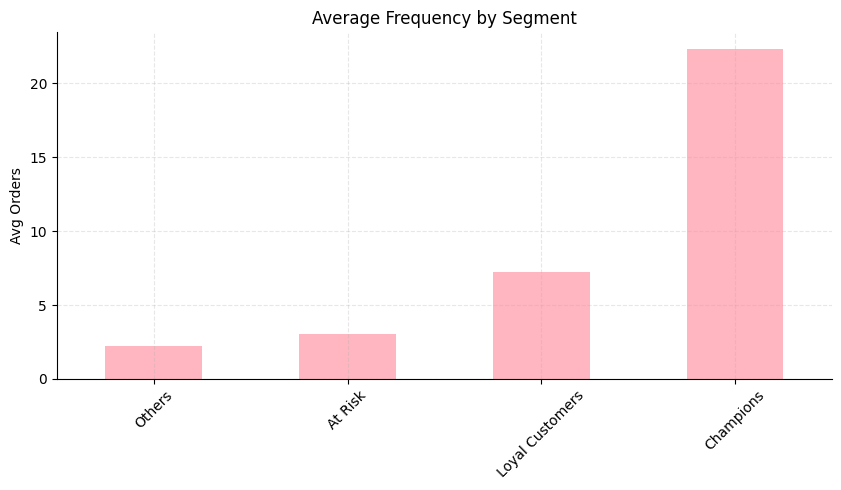

In [ ]:
#average frequency by segment
segment_freq = rfm_table.groupby("Segment")["Frequency"].mean().sort_values()

plt.figure(figsize=(10,4.5))
segment_freq.plot(kind="bar", color="lightpink")

plot_style(plt.gca(), "Average Frequency by Segment", ylabel="Avg Orders")
plt.xticks(rotation=45)
plt.show()

From the plots above, we can reach the conclusion that:
- **High Churn Risk**
The "At Risk" segment is by far the largest, with nearly 3,000 customers, suggesting that a significant portion of your customers has not made a purchase in a long time.The business is successful at acquiring new customers, but a huge number of them are slipping away. The company need according business promotional strategies to win back these people specifically.

- **Solid Loyal Customer Foundation**
The "Loyal Customers" and "Champions" segments combined represent roughly 2,000 customers. While they are fewer in number than the "At Risk" group, having ~750 "Champions" is a strong foundation for the business and these groups should be the focus of rewards campaigns or early access to new products to ensure they won't become a member of "At Risk" segment.

- **Dominance of Champions in Revenue**
Although Champions were the smallest group in terms of "Count" (~750 people), they are the undisputed leaders in revenue, bringing in nearly £9.5 million, indicating that this group contribute most of company's revenue. Company should pay more attention to keep this group of customers to maintain stable revenue growth. Also the Champion group customers have the highest frequency of purchase.



# Summary of Findings
This project transformed 1,067,371 raw transaction rows into a structured, multi-layer customer segmentation model， producing directly actionable outputs for marketing.
The customer base has a classic power-law distribution. Champions (22% of customers) generate 68% of all revenue — a clear case of the 80/20 rule. Meanwhile, Lost customers are the largest single headcount problem (21.7% of base) but contribute only 1.8% of revenue. At Risk (10.5% of base, 8.7% of revenue) — these were once good customers (avg 5.6 purchases, £2,517 spend) but haven't bought in ~360 days. They're slipping into "Lost" territory and are the best win-back opportunity for the business. 

Recommended priorities:
- Protect Champions with VIP programs and early access offers.
- Launch a win-back campaign for At Risk customers within 30 days.
- Accept a level of churn in the Lost segments and focus spend on higher rfm score groups.
